# HW04 Linear regression

Датасет: Price of Used Toyota Corolla Cars 

https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import category_encoders as ce
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,  ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_val_predict
import plotly  

df = pd.read_csv("ToyotaCorolla.csv", index_col=0)


# EDA + Data preparation



# Краткое описание по данным:

Размер датасета: 1436 строк  с 38 колонками.

В основном признаки -- целые числа, причем многие из них бинарные (0 = No, 1 = Yes).

Пропусков нет. Дубликатов строк нет.

Целевая переменная -- Price (то, что будем предсказывать).

In [2]:
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,...,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,...,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,...,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,...,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,...,1,1,0,1,0,1,0,0,0,0


In [3]:
df.tail()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,
1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,Blue,...,1,1,0,1,1,1,0,0,0,0
1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,Grey,...,0,1,0,0,1,1,0,0,0,0
1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,Blue,...,0,1,0,0,0,1,0,0,0,0
1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,Grey,...,0,0,0,0,0,1,0,0,0,0
1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,5,1998,1,Petrol,110,0,Green,...,0,1,0,0,0,0,0,0,0,0


In [4]:
df.shape

(1436, 38)

In [5]:
df.info()


<class 'pandas.DataFrame'>
Index: 1436 entries, 1 to 1442
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Model              1436 non-null   str  
 1   Price              1436 non-null   int64
 2   Age_08_04          1436 non-null   int64
 3   Mfg_Month          1436 non-null   int64
 4   Mfg_Year           1436 non-null   int64
 5   KM                 1436 non-null   int64
 6   Fuel_Type          1436 non-null   str  
 7   HP                 1436 non-null   int64
 8   Met_Color          1436 non-null   int64
 9   Color              1436 non-null   str  
 10  Automatic          1436 non-null   int64
 11  CC                 1436 non-null   int64
 12  Doors              1436 non-null   int64
 13  Cylinders          1436 non-null   int64
 14  Gears              1436 non-null   int64
 15  Quarterly_Tax      1436 non-null   int64
 16  Weight             1436 non-null   int64
 17  Mfr_Guarantee      1436 non-nu

In [6]:
df.describe()

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 1


In [8]:
df.describe(include='str')

,Model,Fuel_Type,Color
count,1436,1436,1436
unique,319,3,10
top,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,Petrol,Grey
freq,109,1264,301


In [9]:
df["Fuel_Type"].unique()

<StringArray>
['Diesel', 'Petrol', 'CNG']
Length: 3, dtype: str

Колонки, где множественные (небинарные) значения:

In [10]:
cols = np.array([col for col in df.columns if df[col].nunique() > 2 and df[col].dtype == 'int64'])
print(cols)

['Price' 'Age_08_04' 'Mfg_Month' 'Mfg_Year' 'KM' 'HP' 'CC' 'Doors' 'Gears'
 'Quarterly_Tax' 'Weight' 'Guarantee_Period']


In [11]:
cols1 = np.array([col for col in df.columns if df[col].nunique() == 2 and df[col].dtype == 'int64'])
print(cols1)

['Met_Color' 'Automatic' 'Mfr_Guarantee' 'BOVAG_Guarantee' 'ABS'
 'Airbag_1' 'Airbag_2' 'Airco' 'Automatic_airco' 'Boardcomputer'
 'CD_Player' 'Central_Lock' 'Powered_Windows' 'Power_Steering' 'Radio'
 'Mistlamps' 'Sport_Model' 'Backseat_Divider' 'Metallic_Rim'
 'Radio_cassette' 'Parking_Assistant' 'Tow_Bar']


Одно уникальное значение в колонке кол-ва  цилиндров, смело удаляем. 

In [12]:
df['Cylinders'].nunique()
df = df.drop('Cylinders', axis=1)

In [13]:
numeric_df = df.loc[:, cols]
numeric_df.describe()
stats = numeric_df.agg(['min', 'max', 'mean', 'median', 'std'])
modes = numeric_df.mode().iloc[0]
stats.loc['mode'] = modes
stats

,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,CC,Doors,Gears,Quarterly_Tax,Weight,Guarantee_Period
min,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,1300.00000,2.000000,3.000000,19.000000,1000.00000,3.000000
max,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,16000.00000,5.000000,6.000000,283.000000,1615.00000,36.000000
mean,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,1576.85585,4.033426,5.026462,87.122563,1072.45961,3.815460
median,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1600.00000,4.000000,5.000000,85.000000,1070.00000,3.000000
std,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,424.38677,0.952677,0.188510,41.128611,52.64112,3.011025
mode,8950.000000,68.000000,1.000000,1999.000000,36000.000000,110.000000,1600.00000,5.000000,5.000000,85.000000,1075.00000,3.000000


In [14]:
binumeric_df = df.loc[:, cols1]
binumeric_df.describe()
stats = binumeric_df.agg(['min', 'max', 'mean', 'median', 'std'])
modes = binumeric_df.mode().iloc[0]
stats.loc['mode'] = modes
stats

,Met_Color,Automatic,Mfr_Guarantee,BOVAG_Guarantee,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
mean,0.674791,0.055710,0.409471,0.895543,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
median,1.000000,0.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
std,0.468616,0.229441,0.491907,0.305959,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
mode,1.000000,0.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
means = binumeric_df.mean()

threshold = 0.01

cols_to_drop = means[(means < threshold) | (means > (1 - threshold))].index.tolist()

print(f"Будут удалены признаки: {cols_to_drop}")


df = df.drop(columns=cols_to_drop)


Будут удалены признаки: ['Parking_Assistant']


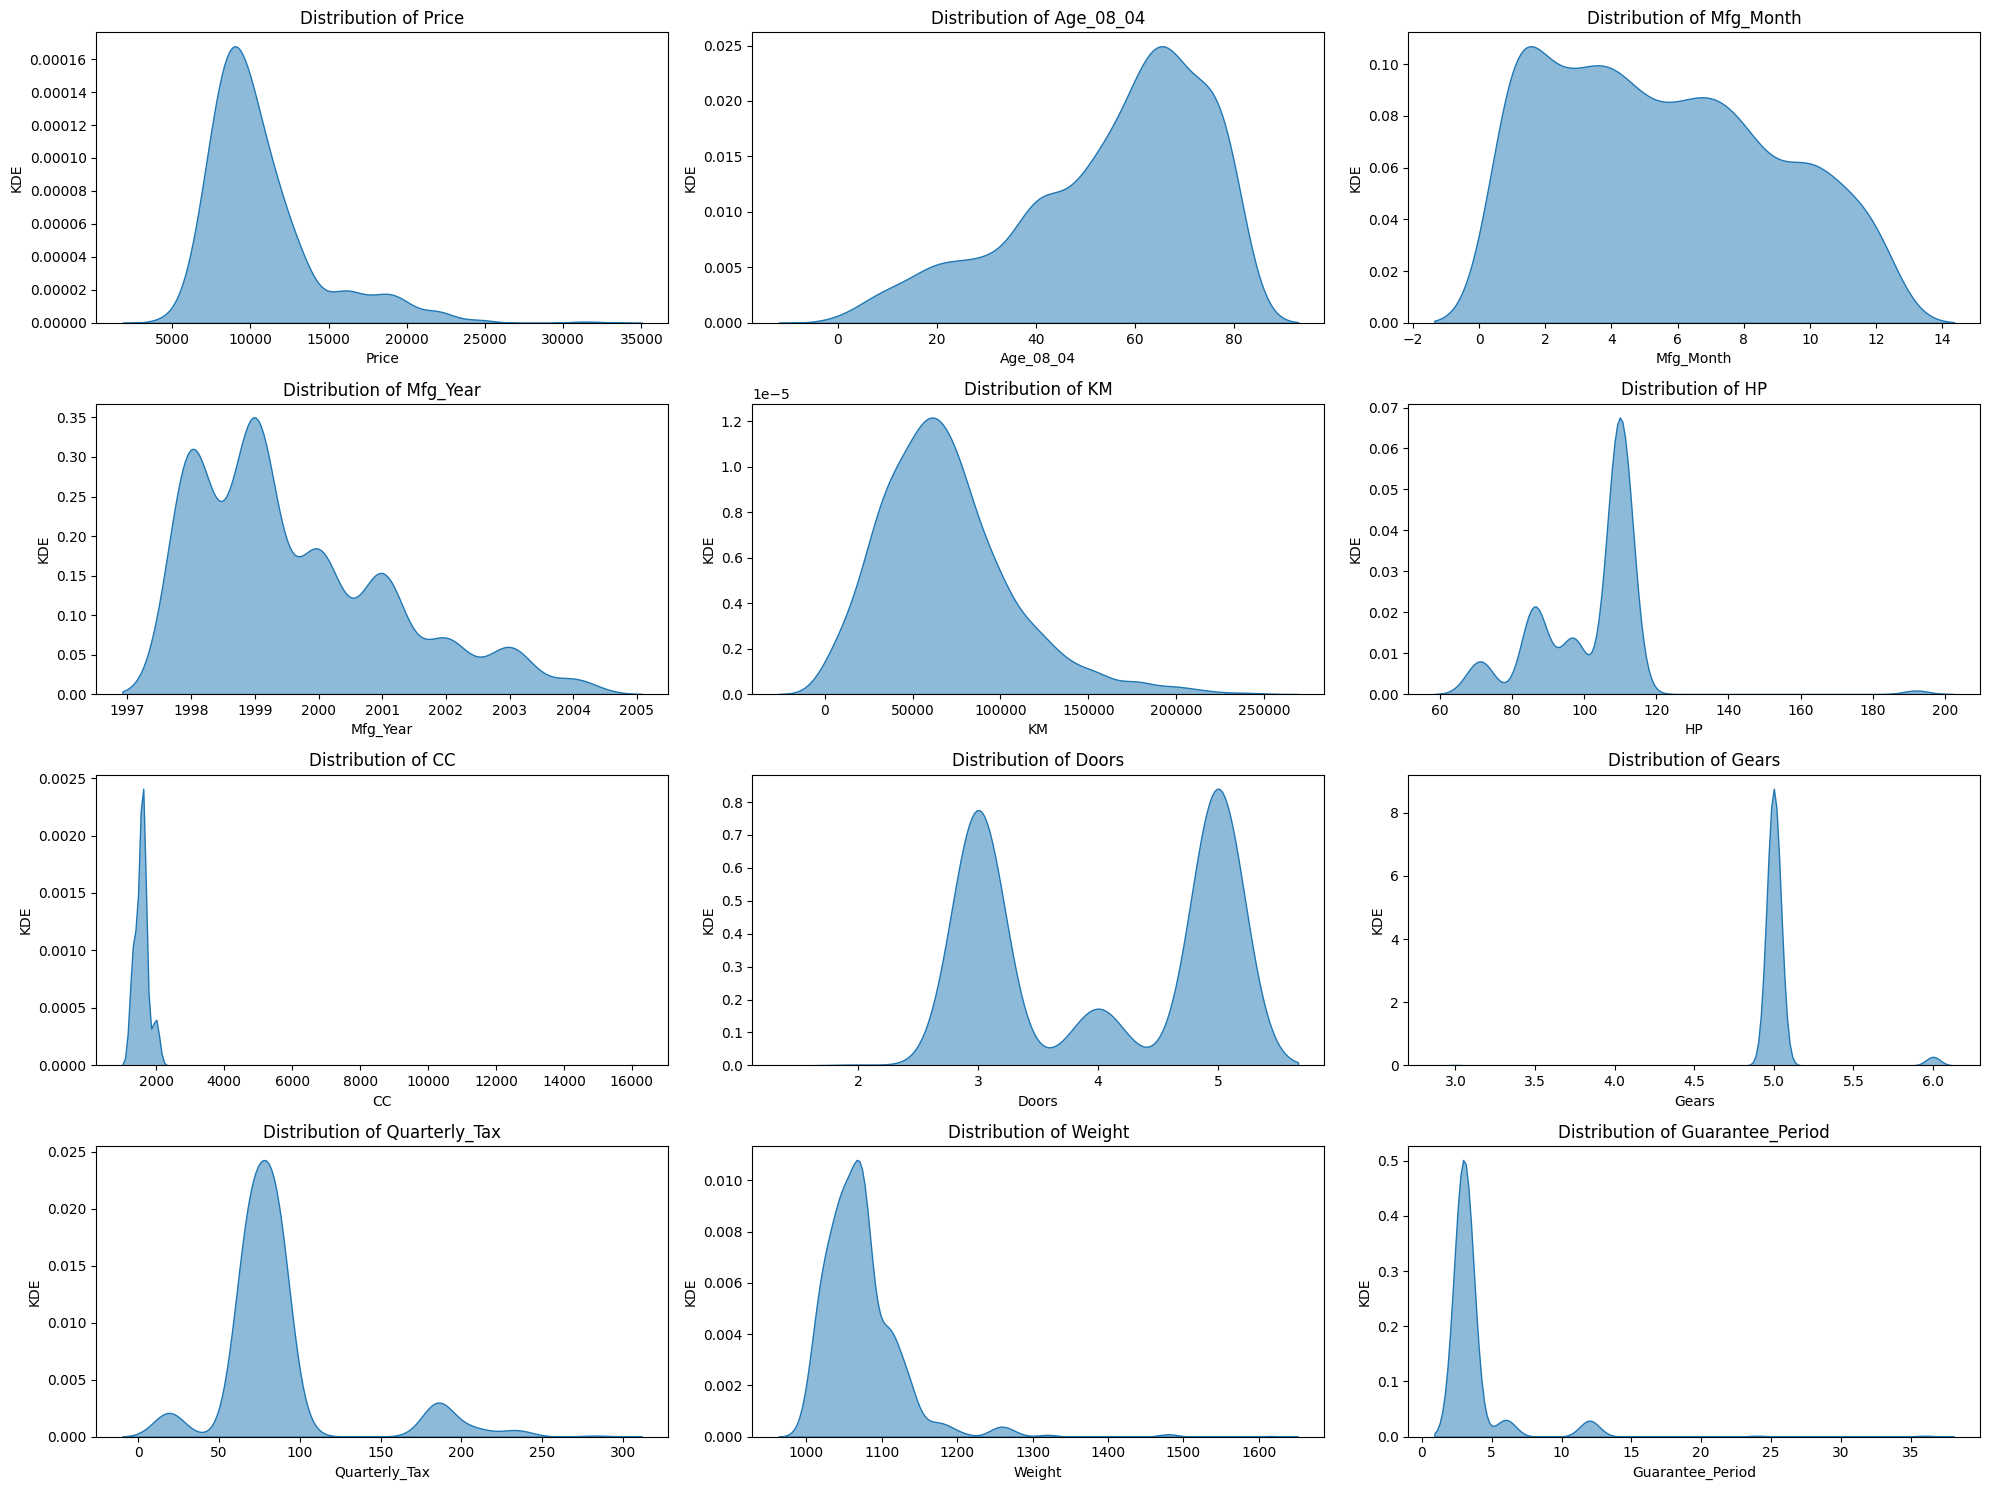

In [16]:

plt.figure(figsize=(20, 15))

for i, column in enumerate(cols[:], 1):  
    plt.subplot(4, 3, i)

    sns.kdeplot(data=df, x=column, 
                fill=True, alpha=0.5)
    
    plt.title(f'Distribution of {column}', fontsize=12)
    plt.xlabel(column)
    plt.ylabel('KDE')

plt.tight_layout()
plt.show()

Тут виден большой разброс данных по почти всем выбранным колонкам.

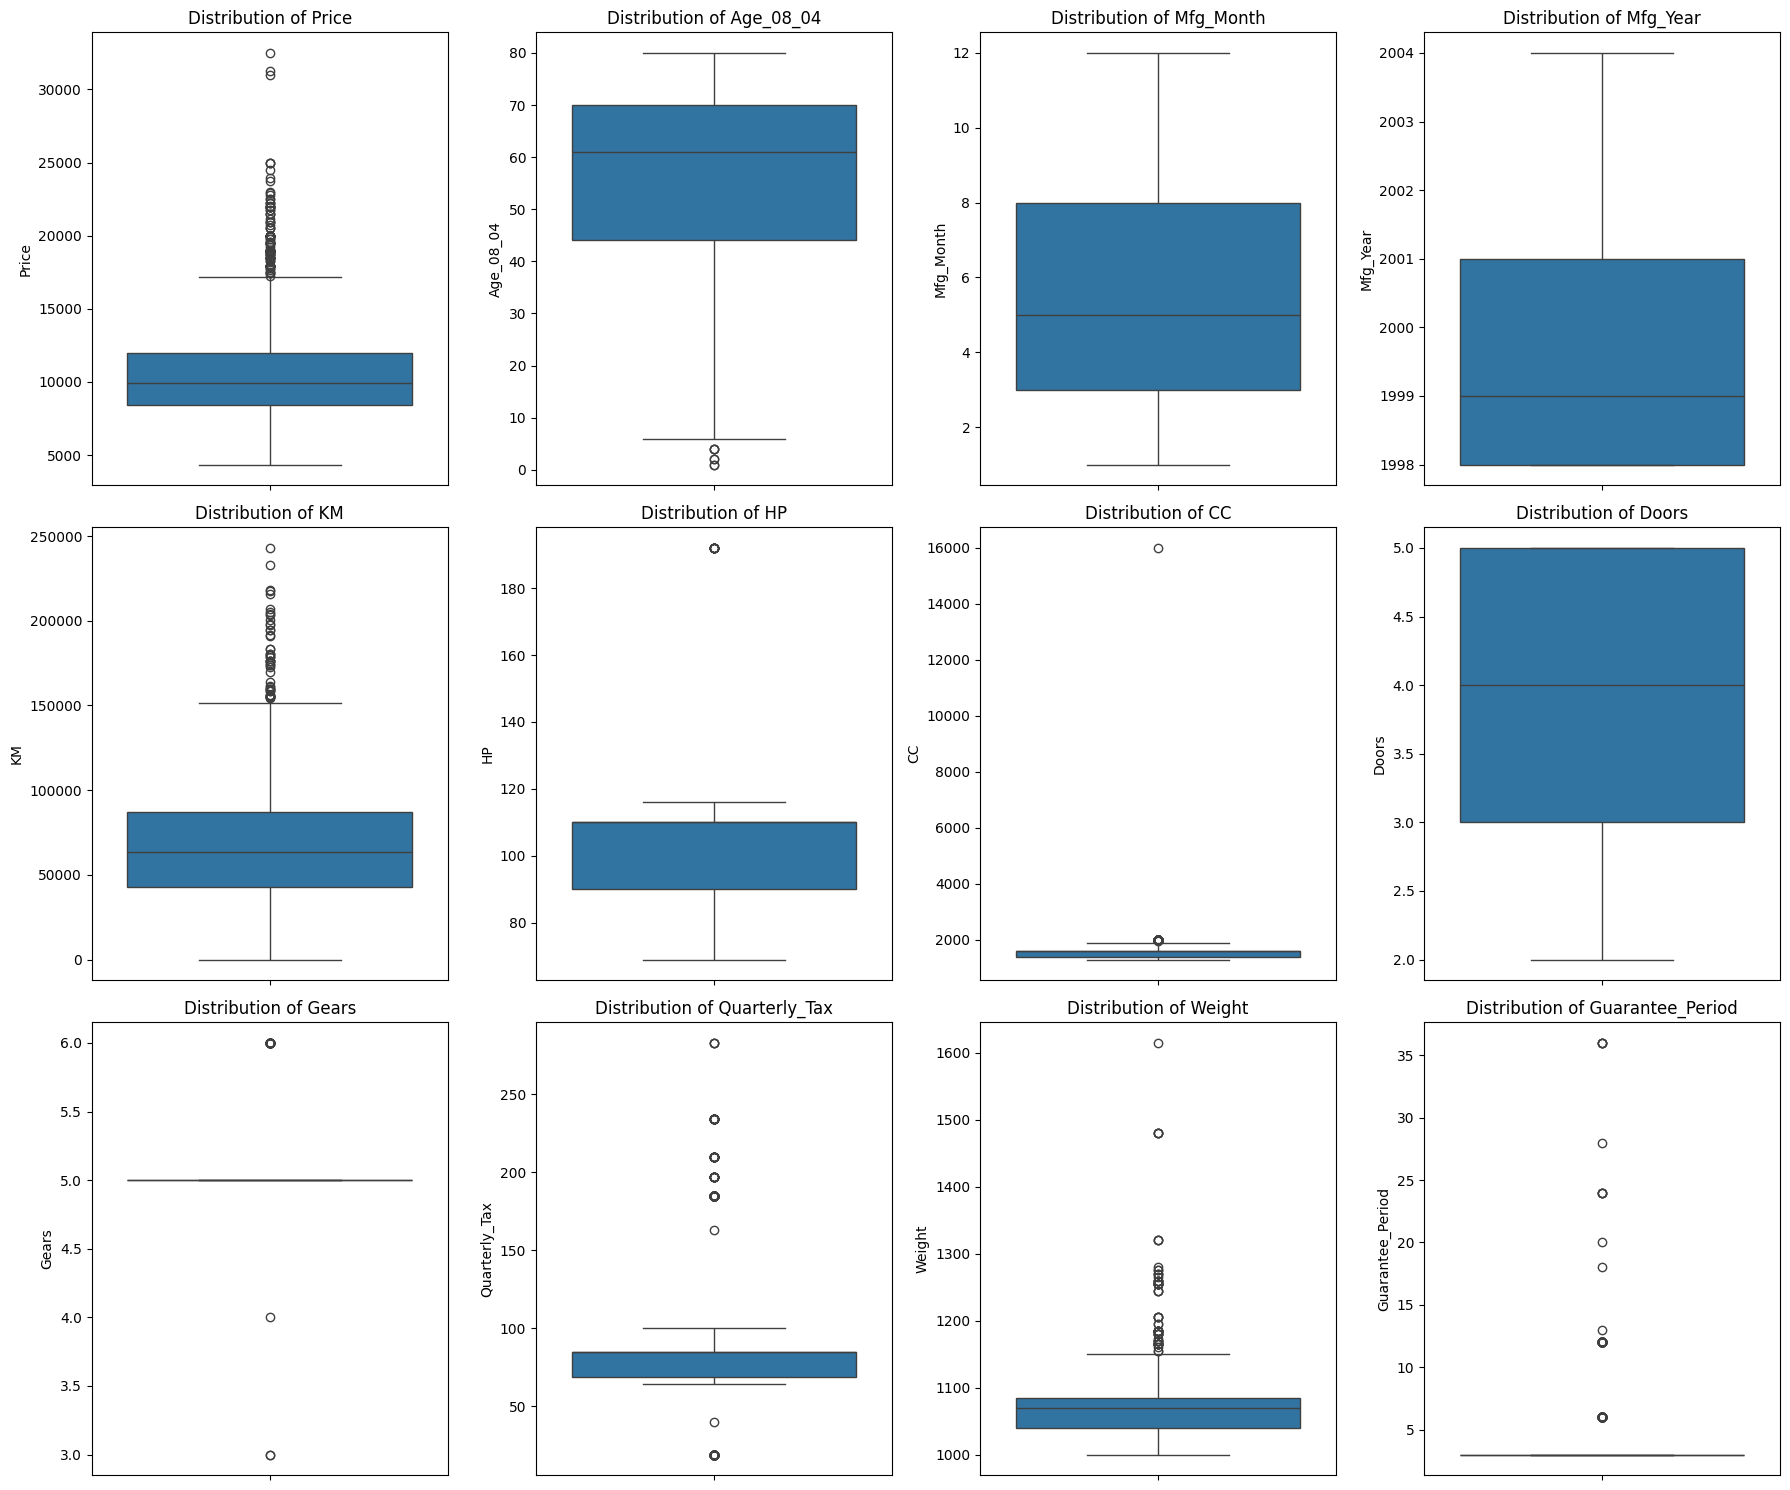

In [17]:
plt.figure(figsize=(18, 15))



for i, column in enumerate(numeric_df, 1): 
    plt.subplot(3, 4, i)
    sns.boxplot(data=df, y=column) 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

Функция для выявления выбросов:

In [18]:
def detect_outliers_y(df, y_column):
   
    y = df[y_column]
    
   
    Q1 = y.quantile(0.25)
    Q3 = y.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_mask = (y < lower_bound) | (y > upper_bound)
        
    return outliers_mask, lower_bound, upper_bound

In [19]:
outliers_mask, lb, ub = detect_outliers_y(df, 'Price')

print(f"Количество выбросов: {outliers_mask.sum()}")
print(f"Процент выбросов: {outliers_mask.mean() * 100:.2f}%")

Количество выбросов: 110
Процент выбросов: 7.66%


Попробуем применить логарифмическую трансформацию, так как >7% выбросов достаточно весомо.

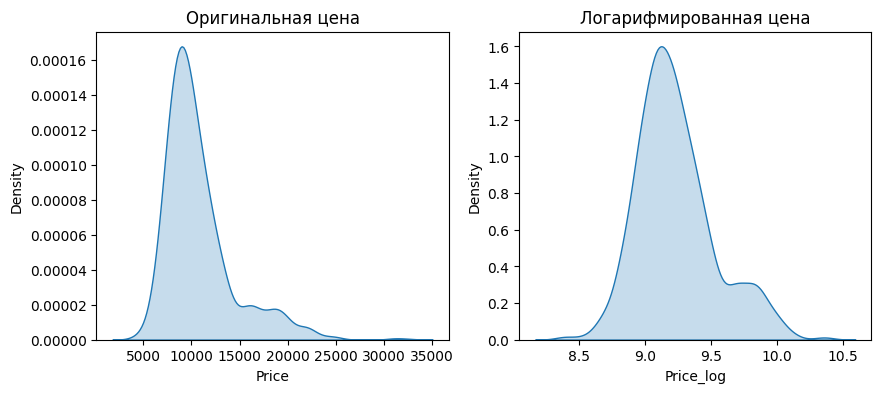

In [20]:
df['Price_log'] = np.log1p(df['Price'])


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(df['Price'], fill=True).set_title('Оригинальная цена')

plt.subplot(1, 2, 2)
sns.kdeplot(df['Price_log'], fill=True).set_title('Логарифмированная цена')
plt.show()

Количество выбросов: 41
Процент выбросов: 2.86%


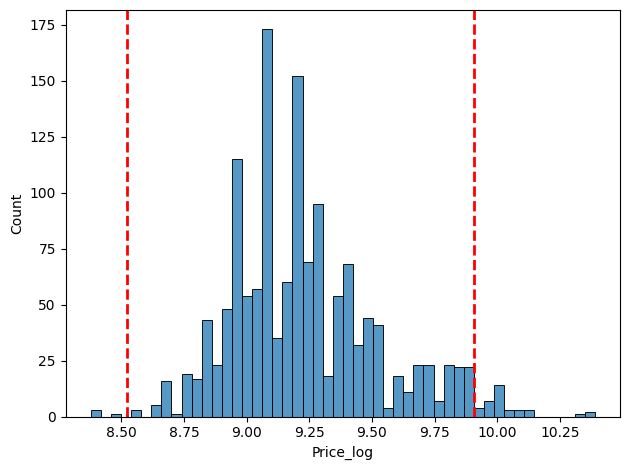

In [21]:

outliers_mask, lb, ub = detect_outliers_y(df, 'Price_log')

print(f"Количество выбросов: {outliers_mask.sum()}")
print(f"Процент выбросов: {outliers_mask.mean() * 100:.2f}%")



sns.histplot(df['Price_log'], bins=50)
plt.axvline(lb, color='red', linestyle='--', linewidth=2, label='Нижняя граница')
plt.axvline(ub, color='red', linestyle='--', linewidth=2, label='верхняя граница')

plt.tight_layout()
plt.show()



Выбросов не так много, не будем их удалять, чтоб не ухудшить модель. Теперь будем предсказывать лог. цену, а потом сделаем обратное преобразование.

In [22]:

df_model = df.drop('Price', axis=1)


In [23]:
df_clean = df_model.copy()
cols_to_trim_up = ['KM', 'Weight', 'HP', 'CC']


limits = {}

for col in cols_to_trim_up:
    limits[f'{col}_up'] = df[col].quantile(0.99)



mask = pd.Series([True] * len(df), index=df.index)

for col in cols_to_trim_up:
    mask &= (df[col] <= limits[f'{col}_up'])

df_clean = df[mask].copy()

print(f"Было : {len(df_model)}, стало: {len(df_clean)}")
print(f"Удалено строк: {len(df_model) - len(df_clean)}")

df_model = df_clean

Было : 1436, стало: 1394
Удалено строк: 42


In [24]:
#df_model = df_model[~outliers_mask]
#print(f"Размер после удаления: {len(df_model)}")

In [25]:
df_model["Gears"].value_counts(normalize=True)

Gears
5    0.972023
6    0.025825
3    0.001435
4    0.000717
Name: proportion, dtype: float64

Почти всегда 5 передач, по сути константный признак, я бы удалил. Но проверим, насколько влияет признак на ценообразование.

In [26]:
print(df.groupby('Gears')['Price'].mean())

Gears
3     9450.000000
4     9950.000000
5    10692.934532
6    12033.372093
Name: Price, dtype: float64


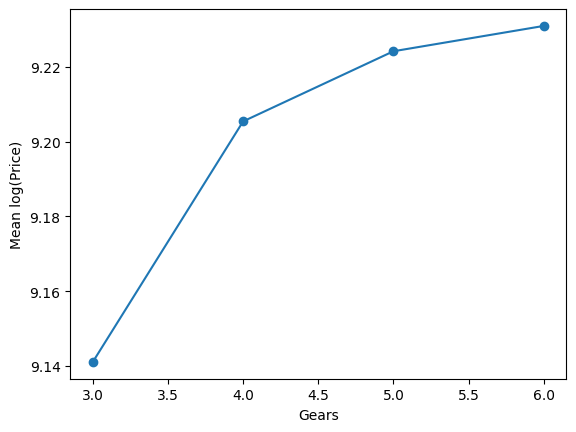

In [27]:
means = df_model.groupby('Gears')['Price_log'].mean()
plt.plot(means.index, means.values, 'o-')
plt.xlabel('Gears')
plt.ylabel('Mean log(Price)')
plt.show()

Тогда не трогаем его. Можно было бы закодировать, но и так уже много признаков.

Два пика на графики распределния, проверим сильно ли влияет этот параметр на цену, в любом случае нам не выгодно делить датасет пополам, так как мало данных станет.

In [28]:
df_model["Doors"].value_counts()

Doors
5    651
3    607
4    134
2      2
Name: count, dtype: int64

In [29]:
print(df.groupby('Doors')['Price'].mean())


Doors
2     8100.000000
3    10107.342444
4     9806.768116
5    11503.209199
Name: Price, dtype: float64


Матрица корреляции

<Axes: >

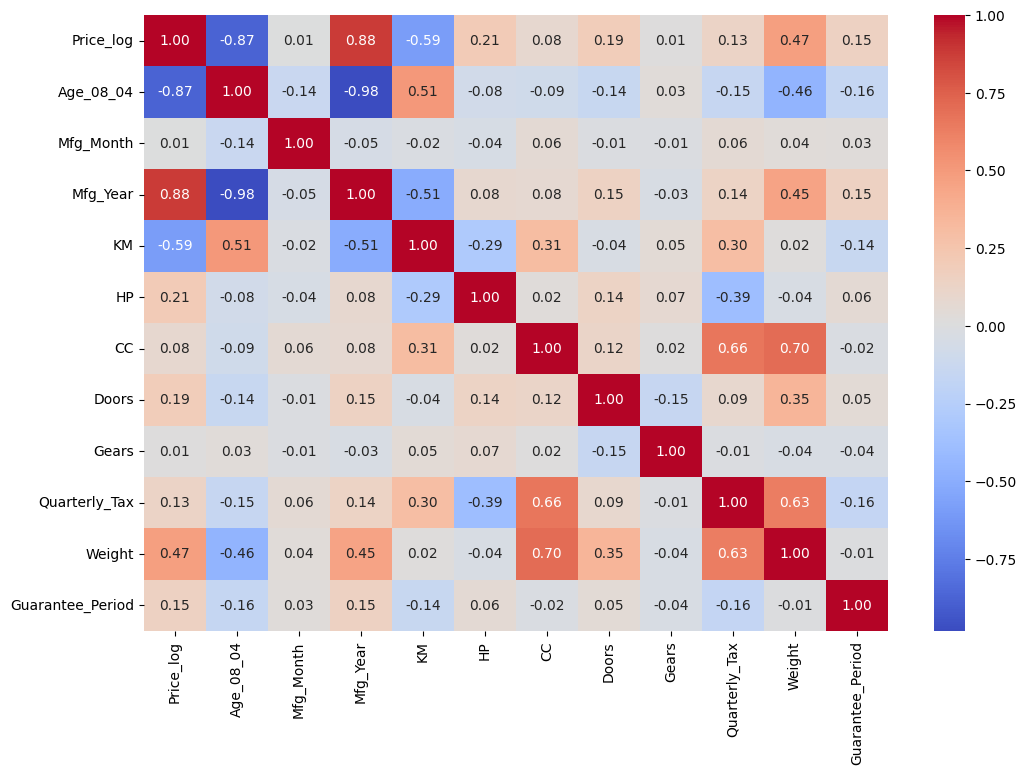

In [30]:
cols = ['Price_log', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM', 'HP', 'CC', 'Doors', 'Gears',
 'Quarterly_Tax', 'Weight', 'Guarantee_Period']
plt.figure(figsize=(12, 8))
sns.heatmap(df_model[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")


Сильная корреляция между Mfg_Year и Age_08_04, между Mfg_Year и Price_log, между Age_08_04 и Price_log. Удалим Age_08_04, так как он повторяет Mfg_Year.

In [31]:
df_model = df_model.drop('Age_08_04', axis=1)

И удалим Mfg_Month с нулевой корреляцией.

In [32]:
df_model = df_model.drop('Mfg_Month', axis=1)

['Met_Color', 'Automatic', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Tow_Bar', 'Price_log']


<Axes: >

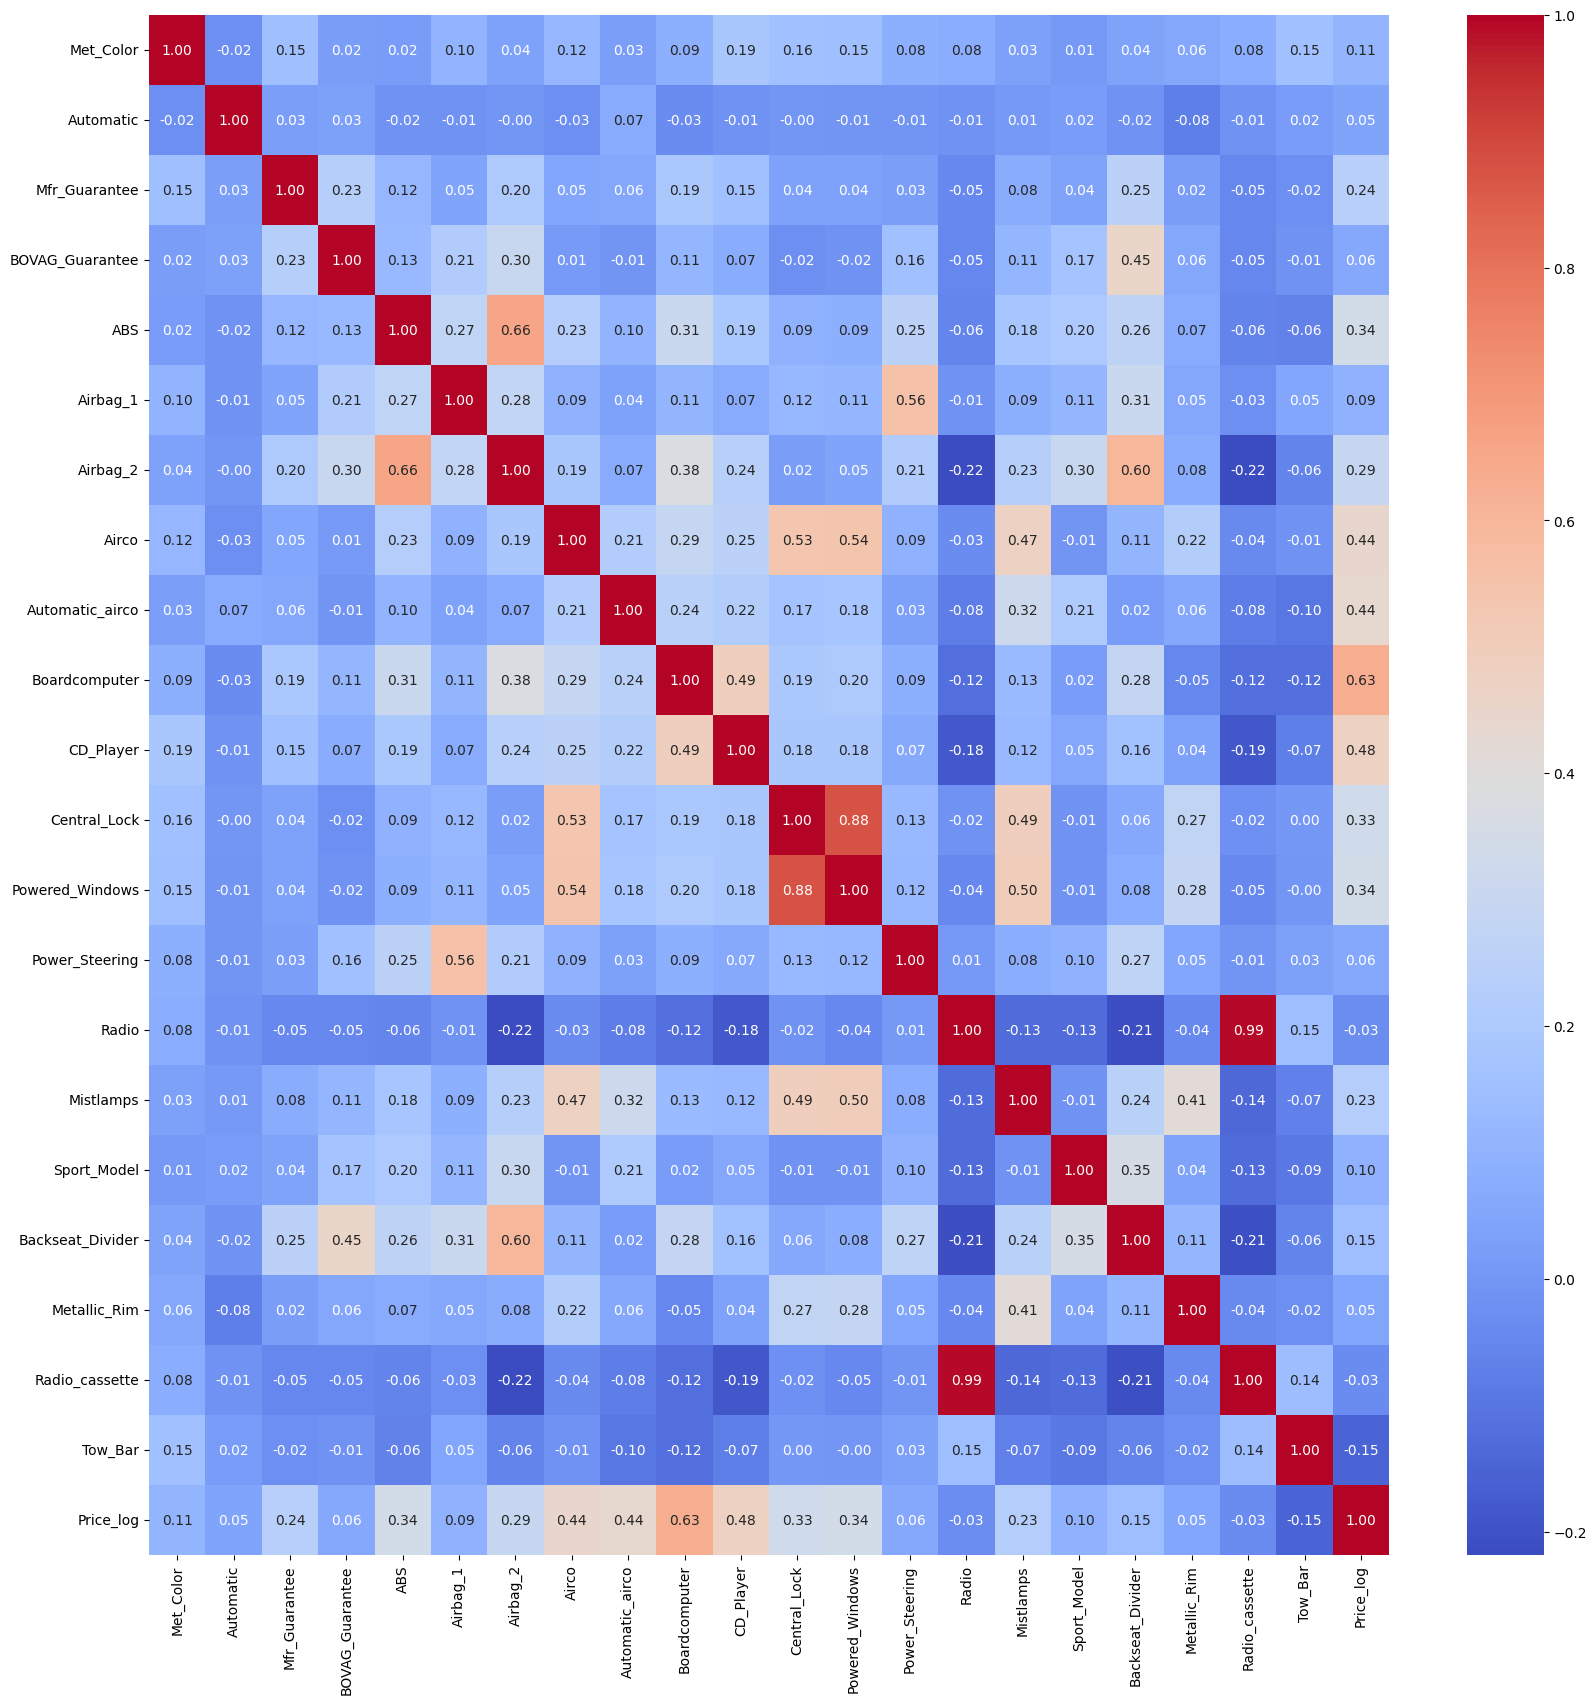

In [33]:
cols= [col for col in df_model.columns if df_model[col].nunique() == 2 and df_model[col].dtype == 'int64'] + ['Price_log']
print(cols)

plt.figure(figsize=(20, 20))
sns.heatmap(df_model[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")



Некоторые признаки слабо коррелируют с таргетом, думаю, стоит удалить. 

Вернемся к Gears, у которого корреляция почти нулевая с таргетом. 

In [34]:
df_model['Gears'].value_counts()

Gears
5    1355
6      36
3       2
4       1
Name: count, dtype: int64

In [35]:
df_model['Radio'].value_counts()

Radio
0    1190
1     204
Name: count, dtype: int64

In [36]:
df_model['Metallic_Rim'].value_counts()

Metallic_Rim
0    1118
1     276
Name: count, dtype: int64

In [37]:
df_model['Automatic'].value_counts()

Automatic
0    1315
1      79
Name: count, dtype: int64

In [38]:
df_model = df_model.drop(['Gears', 'Radio', 'Automatic', 'Radio_cassette', 'Metallic_Rim'], axis=1)

In [39]:
df_model.shape

(1394, 30)

У нас 3 вида топлива:  используем Drop-First One-Hot Encoding

In [40]:
df_model = pd.get_dummies(df_model, columns=['Fuel_Type'], prefix='Fuel', drop_first=True, dtype=int)


In [41]:
with pd.option_context('display.max_rows', None):
    print(df_model['Model'].value_counts())


Model
TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors                            109
TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors                             84
TOYOTA Corolla 1.6 16V LIFTB LINEA LUNA 4/5-Doors                               80
TOYOTA Corolla 1.6 16V LIFTB LINEA TERRA 4/5-Doors                              71
TOYOTA Corolla 1.4 16V VVT I HATCHB TERRA 2/3-Doors                             54
TOYOTA Corolla 1.6 16V SEDAN LINEA TERRA 4/5-Doors                              43
TOYOTA Corolla 1.6 16V VVT I LIFTB TERRA 4/5-Doors                              37
TOYOTA Corolla 1.6 16V VVT I LIFTB SOL 4/5-Doors                                35
TOYOTA Corolla 1.3 16V LIFTB LINEA TERRA 4/5-Doors                              35
TOYOTA Corolla 1.6 16V WAGON LINEA TERRA Stationwagen                           28
TOYOTA Corolla 2.0 DSL HATCHB LINEA TERRA 2/3-Doors                             24
TOYOTA Corolla 1.6 16V VVT I LIFTB LUNA 4/5-Doors                               2

В названии модели есть данные которые и так вынесены в отдельные столбцы. а также есть дубликаты строк просто записанные в разных регистрах. Короче оставим только важную информацию и потом Target Encoding будем использовать. 

In [42]:
import re

def clean_model_simple(name):
    name = name.lower()
    
  
    body = "other"
    if any(x in name for x in ['hatchb', 'hb']): body = 'hatchback'
    elif any(x in name for x in ['liftb', 'lb', 'liftback']): body = 'liftback'
    elif any(x in name for x in ['sedan', 'sdn']): body = 'sedan'
    elif any(x in name for x in ['wagon', 'stationwagen']): body = 'wagon'
    
    trim = "standard"
    if 'terra' in name: trim = 'terra'
    elif 'luna' in name: trim = 'luna'
    elif 'sol' in name: trim = 'sol'
    elif 'g6' in name: trim = 'g6'

    return f"{body}_{trim}"


df_model['Model_Clean'] = df_model['Model'].apply(clean_model_simple)

counts = df_model['Model_Clean'].value_counts()
df_model['Model_Clean'] = df_model['Model_Clean'].apply(lambda x: x if counts[x] >= 10 else 'other_standard')
counts = df_model['Model_Clean'].value_counts()
counts

Model_Clean
hatchback_terra       355
liftback_terra        236
liftback_luna         147
other_terra           126
sedan_terra           107
other_standard         68
hatchback_g6           65
wagon_terra            62
other_sol              52
liftback_sol           48
hatchback_luna         42
hatchback_standard     38
hatchback_sol          25
other_luna             13
sedan_sol              10
Name: count, dtype: int64

In [43]:
df_model["Color"].value_counts()

Color
Grey      285
Blue      280
Red       272
Green     217
Black     184
Silver    118
White      28
Violet      4
Yellow      3
Beige       3
Name: count, dtype: int64

In [44]:
color_analysis = df.groupby('Color')['Price'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

print(color_analysis)


                mean  count
Color                      
Yellow  12531.666667      3
Grey    11927.342193    301
Silver  11070.680328    122
Black   11053.848168    191
Blue    10836.438163    283
Red      9962.697842    278
Green    9836.109091    220
Violet   9575.000000      4
Beige    8933.333333      3
White    8207.903226     31


In [45]:
counts = df_model['Color'].value_counts()
df_model['Color'] = df_model['Color'].apply(lambda x: x if counts[x] > 10 else 'Other')

df_model

,Model,Price,Mfg_Year,KM,HP,Met_Color,Color,CC,Doors,Quarterly_Tax,...,Powered_Windows,Power_Steering,Mistlamps,Sport_Model,Backseat_Divider,Tow_Bar,Price_log,Fuel_Diesel,Fuel_Petrol,Model_Clean
Id,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,2002,46986,90,1,Blue,2000,3,210,...,1,1,0,0,1,0,9.510519,1,0,hatchback_terra
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,2002,72937,90,1,Silver,2000,3,210,...,0,1,0,0,1,0,9.528867,1,0,hatchback_terra
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,2002,41711,90,1,Blue,2000,3,210,...,0,1,0,0,1,0,9.543306,1,0,hatchback_terra
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,2002,48000,90,0,Black,2000,3,210,...,0,1,0,0,1,0,9.612533,1,0,hatchback_terra
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,2002,38500,90,0,Black,2000,3,210,...,1,1,1,0,1,0,9.528867,1,0,hatchback_sol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,1998,20544,86,1,Blue,1300,3,69,...,1,1,1,1,1,0,8.922792,0,1,hatchback_g6
1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,1998,19000,86,0,Grey,1300,3,69,...,0,1,0,1,1,0,9.291552,0,1,hatchback_terra
1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,1998,17016,86,0,Blue,1300,3,69,...,0,1,0,0,1,0,9.047939,0,1,hatchback_terra


По итогу после предобработки осталось 1394 строк и 29 столбцов по сути. 
По данным можно сказать, что они имеют не нормальное распределение. Целевая переменная имеет длинный хвост справа. Вообще выбросов многовато. 
Из 3 строковых признаков один немногочисленный и важный (тип топлива) был закодирован One-Hot encoding, названия моделей машин были предоьработаны, очищены от лишней дублирующейся информации и закодированы TargetEncoder'ом, как и признак color. Были незначительные признаки или которые были связаны линейно с другими признаками, почистил их. Цена была логарифмирована для небольшого улучшения распределения и выявления самых значительных выбросов для последующего удаления. Какие-то новые признаки из существующих плодить не стал, так как размерность и так не маленькая. Масштабирование будет использоваться уже непосредственно в обучении модели: я выбрал RobustScaler, так как он устойчив к выбросам. 

# Data splitting 

Выборку разделю с помощью кросс-валидации на 5 фолдов (это будет делаться в пайплайне в момент обучения модели уже). 
Разделять выборку на train/test нужно, чтоб можно было проверить поведение модели на "незнакомых" данных. Если бы мы обучали и проверяли модель на одних и тех же данных, произошло бы переобучение, модель просто запомнила бы правильные ответы на имеющихся данных и на новых данных бы показала плохие показатели. 

# Learning

In [46]:
from sklearn.metrics import root_mean_squared_error


X = df_model.drop(['Price_log', 'Price', 'Model'], axis=1, errors='ignore')
y = df_model['Price_log']
models = [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=0.01))
]

results = []

for name, model in models:
    pipe = Pipeline([
        ('encoder', ce.TargetEncoder(cols=['Model_Clean', 'Color'], smoothing=10)),
        ('scaler', RobustScaler()),
        ('regressor', model)
    ])
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
 
    scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2')
    
  
    y_pred_log = cross_val_predict(pipe, X, y, cv=kf)
    y_true_real = np.expm1(y)
    y_pred_real = np.expm1(y_pred_log)
    r2_real = r2_score(y_true_real, y_pred_real) 
    mae = mean_absolute_error(y_true_real, y_pred_real)
    rmse = root_mean_squared_error(y_true_real, y_pred_real)
    
    results.append({
        'Model': name,
        'R2_mean': scores.mean(),
        'R2_Real': r2_real,
        'MAE': mae,
        'RMSE': rmse
    })

comparison_df = pd.DataFrame(results)
comparison_df

,Model,R2_mean,R2_Real,MAE,RMSE
0,Linear,0.856997,0.897273,776.103459,1028.043039
1,Ridge,0.857630,0.898398,773.000257,1022.398496
2,Lasso,0.831296,0.871256,834.030031,1150.888703


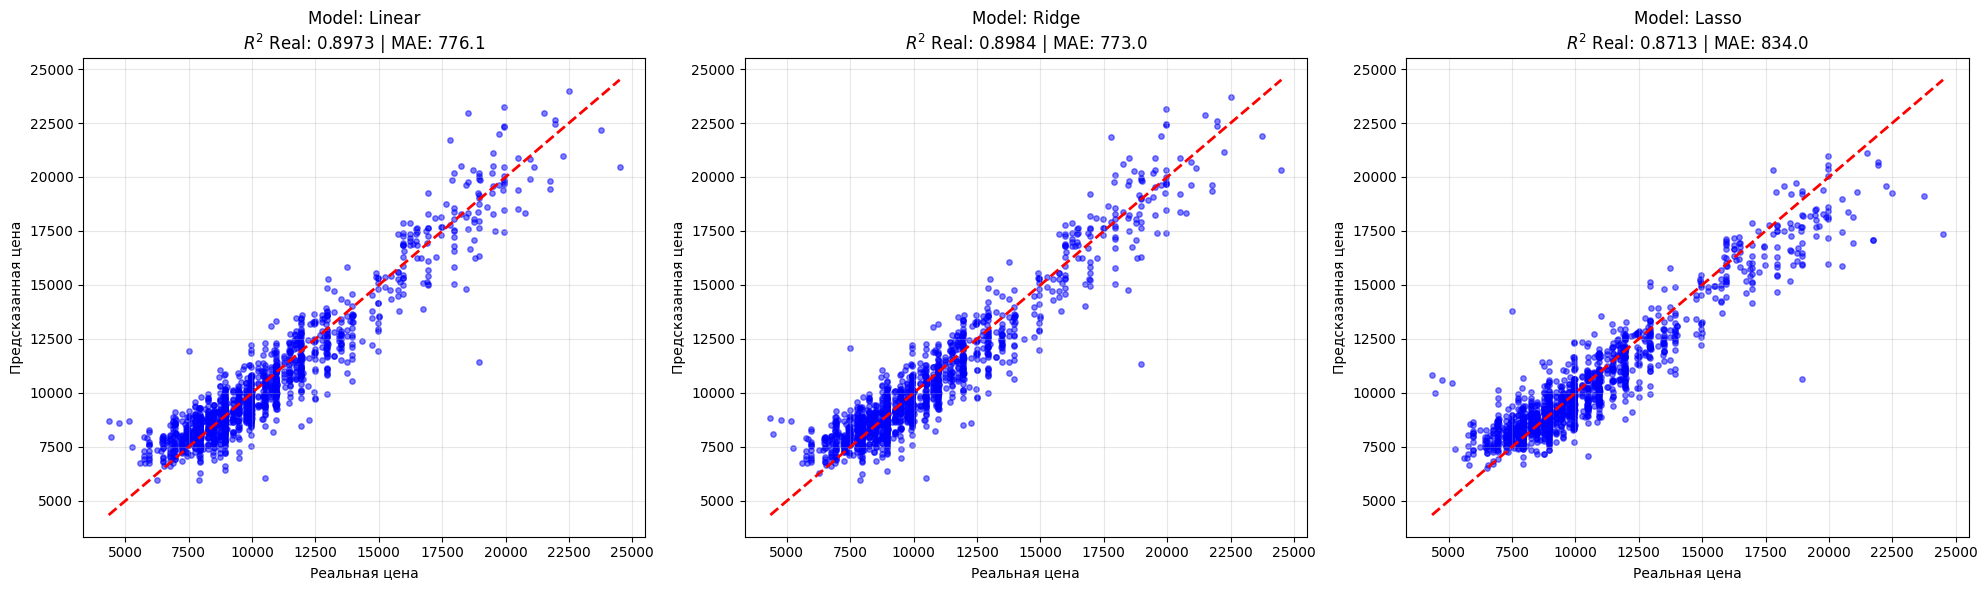

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 6))

model_names = [res['Model'] for res in results]

for i, name in enumerate(model_names):
    plt.subplot(1, 3, i + 1)
    
    row = comparison_df[comparison_df['Model'] == name].iloc[0]
    r2_r = row['R2_Real']
    mae_r = row['MAE']
    
   
    current_model = [m for n, m in models if n == name][0]
    pipe = Pipeline([
        ('encoder', ce.TargetEncoder(cols=['Model_Clean', 'Color'], smoothing=10)),
        ('scaler', RobustScaler()),
        ('regressor', current_model)
    ])
    
    y_pred_log = cross_val_predict(pipe, X, y, cv=kf)
    y_pred_real = np.expm1(y_pred_log)
    y_true_real = np.expm1(y)
    
    # Рисуем точки (реальность vs предсказание)
    plt.scatter(y_true_real, y_pred_real, alpha=0.5, color='blue', s=15)
    
    # Линия идеального прогноза
    limits = [y_true_real.min(), y_true_real.max()]
    plt.plot(limits, limits, color='red', linestyle='--', linewidth=2)
    
    plt.title(f'Model: {name}\n$R^2$ Real: {r2_r:.4f} | MAE: {mae_r:.1f}')
    plt.xlabel('Реальная цена')
    plt.ylabel('Предсказанная цена')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Попробуем поискать гиперпараметры получше для Ridge

In [48]:
from sklearn.linear_model import RidgeCV


alphas = np.logspace(-3, 3, 50) 

ridge_cv_pipe = Pipeline([
    ('encoder', ce.TargetEncoder(cols=['Model_Clean', 'Color'], smoothing=10)),
    ('scaler', RobustScaler()),
    ('regressor', RidgeCV(alphas=alphas, scoring='r2', cv=kf))
])

ridge_cv_pipe.fit(X, y)

best_alpha = ridge_cv_pipe.named_steps['regressor'].alpha_
print(f"Лучшее значение alpha: {best_alpha:.4f}")

y_pred_log = cross_val_predict(ridge_cv_pipe, X, y, cv=kf)
y_pred_real = np.expm1(y_pred_log)
y_true_real = np.expm1(y)

print(f"Новый R2_Real: {r2_score(y_true_real, y_pred_real):.4f}")
print(f"Новый MAE: {mean_absolute_error(y_true_real, y_pred_real):.2f}")


Лучшее значение alpha: 1.1514
Новый R2_Real: 0.8980
Новый MAE: 774.13


Одинаково 

Теперь попробуем для Lasso

In [49]:
from sklearn.model_selection import GridSearchCV


pipe = Pipeline([
    ('encoder', ce.TargetEncoder(cols=['Model_Clean', 'Color'], smoothing=10)),
    ('scaler', RobustScaler()),
    ('regressor', Lasso(max_iter=10000)) 
])

param_grid = {
    'regressor__alpha': np.logspace(-5, 1, 100), # От 0.00001 до 10
    'encoder__smoothing': np.linspace(1, 50, 2)            
}


grid_search = GridSearchCV(pipe, param_grid, cv=kf, scoring='r2', n_jobs=-1)


grid_search.fit(X, y)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2(логарифмированная цена): {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_real = np.expm1(cross_val_predict(best_model, X, y, cv=kf))
r2_real = r2_score(y_true_real, y_pred_real)


mae = mean_absolute_error(y_true_real, y_pred_real)
rmse = root_mean_squared_error(y_true_real, y_pred_real)
mape = np.mean(np.abs((y_true_real - y_pred_real) / y_true_real)) * 100


results=[]
results.append({
    'Model': 'Lasso',
    'R2': r2_real,
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape
    })

comparison_df1 = pd.DataFrame(results)
comparison_df1



Лучшие параметры: {'encoder__smoothing': np.float64(1.0), 'regressor__alpha': np.float64(0.00043287612810830614)}
Лучший R2(логарифмированная цена): 0.8581


,Model,R2,MAE,RMSE,MAPE
0,Lasso,0.89863,769.898634,1021.228269,7.733546


Тут подобрались лучшие гиперпараметры
RMSE > MAE, что ожидаемо, так как выбросов достаточно в датасете. 
R2 -- главный показатель качества, достаточно высок. 

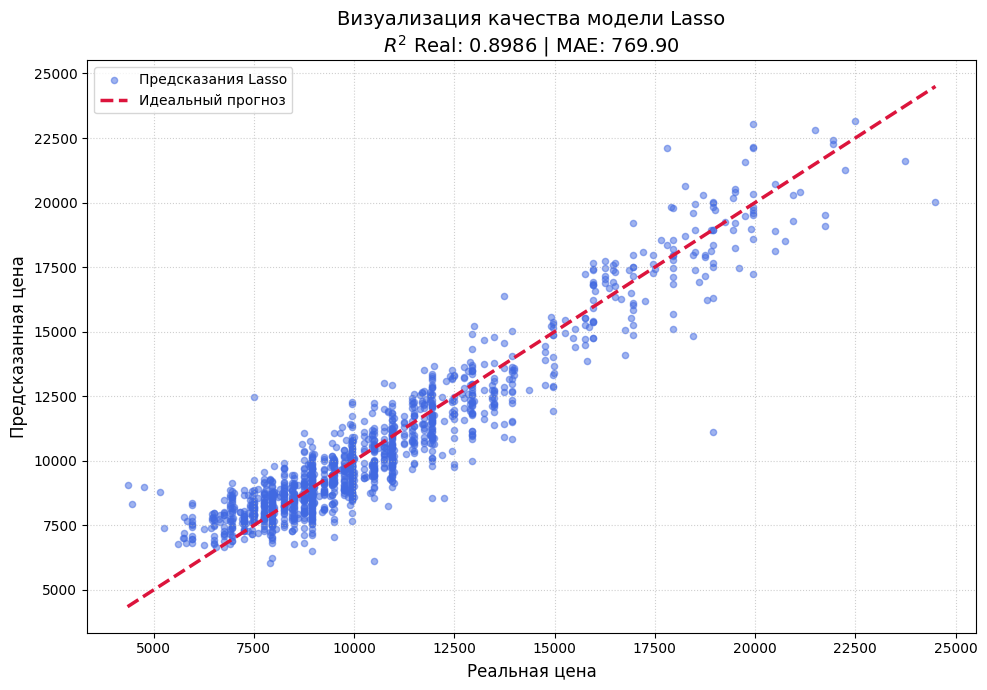

In [50]:

plt.figure(figsize=(10, 7))
plt.scatter(y_true_real, y_pred_real, alpha=0.5, color='royalblue', s=20, label='Предсказания Lasso')

limits = [y_true_real.min(), y_true_real.max()]
plt.plot(limits, limits, color='crimson', linestyle='--', linewidth=2.5, label='Идеальный прогноз')

plt.title(f"Визуализация качества модели Lasso\n$R^2$ Real: {r2_real:.4f} | MAE: {mae:.2f}", fontsize=14)
plt.xlabel('Реальная цена', fontsize=12)
plt.ylabel('Предсказанная цена', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()


## Вывод по обучению моделей
Были рассмотрены базовая Линейная регрессия, Ridge, Lasso

После подборов гиперпараметра alpha в последних двух оказалось, что модель Lasso показала себя наилучшим образом. У Ridge в подборе участвовал RidgeCV, оптимизированный и более быстрый, чем GridSearchCV, который использовался для Lasso. 


-  ##### Какие метрики вы использовали для сравнения моделей?
Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?).
Использовал R2, MAE, RMSE. Первые две метрики наиболее важны, так как на моих данных с выбросами RMSE не сильно показательна. R2 показывает, насколько модель объясняет ценообразование.
-  ##### На какой части выборки вы считали метрики?
На тестовой
- ##### Какая модель по итогу справилась лучше?
Lasso
-  ##### Насколько хорошие получились результаты?
Ошибка MAPE ~7,8%. Mодель объясняет почти 90% разброса цен.
-  ##### Чем докажете, что ваша модель не переобучилась
С помощью кросс-валидации модель была проверена 5 раз на разных кусках данных, и результат везде был стабильно высоким.